## Penjelasan Dan Output Soal 2

In [1]:
import random

import matplotlib.pyplot as plt

Kode ini mengimpor library yang dibutuhkan. random digunakan untuk mengacak urutan tugas awal, sedangkan matplotlib.pyplot digunakan untuk membuat grafik perubahan cost setiap iterasi.

In [2]:
tasks = ['A', 'B', 'C', 'D', 'E']

task_duration = {
    'A': 4,
    'B': 2,
    'C': 7,
    'D': 3,
    'E': 5
}

task_priority = {
    'A': 3,
    'B': 5,
    'C': 2,
    'D': 4,
    'E': 1
}

Kode ini mendefinisikan daftar tugas, durasi setiap tugas, dan prioritas setiap tugas. Data ini menjadi dasar untuk menghitung biaya penjadwalan.

In [3]:
def calculate_cost(schedule):
    total_cost = 0
    completion_time = 0

    for task in schedule:
        completion_time += task_duration[task]
        total_cost += completion_time * task_priority[task]

    return total_cost

Fungsi calculate_cost(schedule) digunakan untuk menghitung total cost dari suatu urutan tugas. Cost dihitung berdasarkan waktu selesai setiap tugas yang dikalikan dengan prioritas tugas tersebut.

In [4]:
def get_best_neighbor(schedule):
    best_neighbor = schedule[:]
    best_cost = calculate_cost(schedule)

    for i in range(len(schedule)):
        for j in range(i + 1, len(schedule)):
            neighbor = schedule[:]
            neighbor[i], neighbor[j] = neighbor[j], neighbor[i]

            neighbor_cost = calculate_cost(neighbor)

            if neighbor_cost < best_cost:
                best_neighbor = neighbor
                best_cost = neighbor_cost

    return best_neighbor, best_cost

Fungsi get_best_neighbor(schedule) digunakan untuk mencari susunan tugas tetangga terbaik. Program mencoba menukar posisi dua tugas, lalu memilih susunan dengan cost paling kecil.

In [5]:
def hill_climbing():
    current_schedule = tasks[:]
    random.shuffle(current_schedule)

    initial_schedule = current_schedule[:]
    initial_cost = calculate_cost(initial_schedule)

    iteration = 0
    history = []

    print("Solusi awal:", initial_schedule)
    print("Cost awal:", initial_cost)
    print()

    history.append(initial_cost)

    while True:
        current_cost = calculate_cost(current_schedule)
        neighbor, neighbor_cost = get_best_neighbor(current_schedule)

        if neighbor_cost < current_cost:
            iteration += 1
            current_schedule = neighbor
            history.append(neighbor_cost)

            print("Iterasi ke-", iteration)
            print("Solusi:", current_schedule)
            print("Cost:", neighbor_cost)
            print()
        else:
            print("Solusi optimal lokal telah ditemukan")
            break

    return initial_schedule, initial_cost, current_schedule, calculate_cost(current_schedule), history

Fungsi hill_climbing() menjalankan algoritma Hill Climbing. Program membuat susunan tugas awal secara acak, lalu terus mencari susunan baru yang memiliki cost lebih kecil sampai tidak ada perbaikan lagi.

In [6]:
def plot_cost(history):
    plt.figure(figsize=(7, 5))
    plt.plot(range(len(history)), history, marker="o")
    plt.title("Perubahan Cost Setiap Iterasi")
    plt.xlabel("Iterasi")
    plt.ylabel("Cost")
    plt.grid(True)
    plt.show()

Fungsi plot_cost(history) digunakan untuk menampilkan grafik perubahan cost dari setiap iterasi. Grafik ini membantu melihat apakah nilai cost semakin menurun selama proses optimasi.

In [7]:
initial_schedule, initial_cost, best_schedule, final_cost, history = hill_climbing()

print("Solusi terbaik:", best_schedule)
print("Total cost akhir:", final_cost)

Solusi awal: ['D', 'E', 'C', 'B', 'A']
Cost awal: 198

Iterasi ke- 1
Solusi: ['D', 'B', 'C', 'E', 'A']
Cost: 141

Iterasi ke- 2
Solusi: ['D', 'B', 'A', 'E', 'C']
Cost: 120

Iterasi ke- 3
Solusi: ['B', 'D', 'A', 'E', 'C']
Cost: 113

Iterasi ke- 4
Solusi: ['B', 'D', 'A', 'C', 'E']
Cost: 110

Solusi optimal lokal telah ditemukan
Solusi terbaik: ['B', 'D', 'A', 'C', 'E']
Total cost akhir: 110


Kode ini menjalankan fungsi hill_climbing(), lalu menampilkan solusi terbaik dan total cost akhir. Hasil proses juga disimpan ke dalam variabel history untuk divisualisasikan.

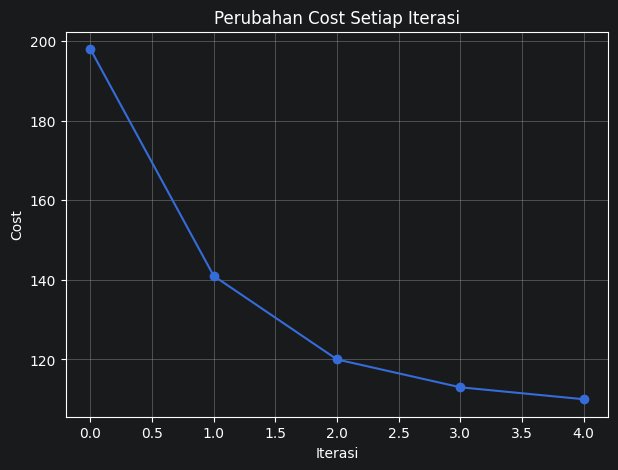

In [8]:
plot_cost(history)

Kode ini memanggil fungsi plot_cost(history) untuk menampilkan grafik perubahan cost. Grafik menunjukkan penurunan cost dari solusi awal sampai solusi optimal lokal ditemukan.